In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name       :", torch.cuda.get_device_name(0))
else:
    print("No GPU is currently available.")

PyTorch version: 2.11.0+cu128
CUDA available : True
GPU name       : Tesla T4


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

print("Google Drive connected successfully.")

Mounted at /content/drive
Google Drive connected successfully.


In [3]:
# ============================================================
# STEP 3: IMPORT LIBRARIES, SET SEED, AND DEVICE
# ============================================================

import os
import math
import json
import random
import time

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

import sentencepiece as spm


# ------------------------------------------------------------
# FIX RANDOM SEED
# ------------------------------------------------------------

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)


# ------------------------------------------------------------
# DEVICE
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


In [4]:
# ============================================================
# STEP 4: SET PROJECT PATHS
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/NNDL_English_Hindi_Translator"

PROCESSED_DATA_DIR = os.path.join(
    PROJECT_ROOT,
    "data",
    "processed"
)

TOKENIZER_DIR = os.path.join(
    PROJECT_ROOT,
    "tokenizers"
)

MODEL_DIR = os.path.join(
    PROJECT_ROOT,
    "saved_models",
    "transformer"
)

RESULTS_PLOTS_DIR = os.path.join(
    PROJECT_ROOT,
    "results",
    "plots"
)

RESULTS_METRICS_DIR = os.path.join(
    PROJECT_ROOT,
    "results",
    "metrics"
)


TRAIN_PATH = os.path.join(
    PROCESSED_DATA_DIR,
    "train_clean_300k.parquet"
)

VALIDATION_PATH = os.path.join(
    PROCESSED_DATA_DIR,
    "validation_clean.parquet"
)

ENGLISH_TOKENIZER_PATH = os.path.join(
    TOKENIZER_DIR,
    "english_bpe.model"
)

HINDI_TOKENIZER_PATH = os.path.join(
    TOKENIZER_DIR,
    "hindi_bpe.model"
)

CONFIG_PATH = os.path.join(
    TOKENIZER_DIR,
    "tokenizer_config.json"
)


# Create output folders if needed
os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

os.makedirs(
    RESULTS_PLOTS_DIR,
    exist_ok=True
)

os.makedirs(
    RESULTS_METRICS_DIR,
    exist_ok=True
)


print("Project root exists :", os.path.exists(PROJECT_ROOT))
print("Training data exists:", os.path.exists(TRAIN_PATH))
print("Validation exists   :", os.path.exists(VALIDATION_PATH))
print("English BPE exists  :", os.path.exists(ENGLISH_TOKENIZER_PATH))
print("Hindi BPE exists    :", os.path.exists(HINDI_TOKENIZER_PATH))
print("Config exists       :", os.path.exists(CONFIG_PATH))

Project root exists : True
Training data exists: True
Validation exists   : True
English BPE exists  : True
Hindi BPE exists    : True
Config exists       : True


In [5]:
# ============================================================
# STEP 5: LOAD TOKENIZER CONFIGURATION
# ============================================================

with open(
    CONFIG_PATH,
    "r",
    encoding="utf-8"
) as file:

    tokenizer_config = json.load(file)


print("Tokenizer configuration loaded successfully.")

print(json.dumps(
    tokenizer_config,
    indent=4
))

Tokenizer configuration loaded successfully.
{
    "training_pairs": 300000,
    "random_seed": 42,
    "english_vocab_size": 16000,
    "hindi_vocab_size": 16000,
    "pad_id": 0,
    "unk_id": 1,
    "bos_id": 2,
    "eos_id": 3,
    "max_sequence_length": 64,
    "max_content_tokens": 62,
    "training_word_length_limit": 50,
    "english_tokenizer": "english_bpe.model",
    "hindi_tokenizer": "hindi_bpe.model"
}


In [6]:
# ============================================================
# STEP 6: EXTRACT TOKENIZER CONFIGURATION VALUES
# ============================================================

PAD_ID = tokenizer_config["pad_id"]
UNK_ID = tokenizer_config["unk_id"]
BOS_ID = tokenizer_config["bos_id"]
EOS_ID = tokenizer_config["eos_id"]

MAX_SEQUENCE_LENGTH = tokenizer_config[
    "max_sequence_length"
]

ENGLISH_VOCAB_SIZE = tokenizer_config[
    "english_vocab_size"
]

HINDI_VOCAB_SIZE = tokenizer_config[
    "hindi_vocab_size"
]


print("Configuration values extracted successfully.")
print("PAD ID              :", PAD_ID)
print("UNK ID              :", UNK_ID)
print("BOS ID              :", BOS_ID)
print("EOS ID              :", EOS_ID)
print("Max sequence length :", MAX_SEQUENCE_LENGTH)
print("English vocab size  :", ENGLISH_VOCAB_SIZE)
print("Hindi vocab size    :", HINDI_VOCAB_SIZE)

Configuration values extracted successfully.
PAD ID              : 0
UNK ID              : 1
BOS ID              : 2
EOS ID              : 3
Max sequence length : 64
English vocab size  : 16000
Hindi vocab size    : 16000


In [7]:
# ============================================================
# STEP 7: LOAD SENTENCEPIECE TOKENIZERS
# ============================================================

english_tokenizer = spm.SentencePieceProcessor()
english_tokenizer.load(
    ENGLISH_TOKENIZER_PATH
)

hindi_tokenizer = spm.SentencePieceProcessor()
hindi_tokenizer.load(
    HINDI_TOKENIZER_PATH
)

print("Both tokenizers loaded successfully.")
print(
    "English tokenizer vocabulary:",
    english_tokenizer.get_piece_size()
)
print(
    "Hindi tokenizer vocabulary:",
    hindi_tokenizer.get_piece_size()
)

Both tokenizers loaded successfully.
English tokenizer vocabulary: 16000
Hindi tokenizer vocabulary: 16000


In [8]:
# ============================================================
# STEP 8: LOAD TRAINING AND VALIDATION DATA
# ============================================================

train_df = pd.read_parquet(
    TRAIN_PATH
)

validation_df = pd.read_parquet(
    VALIDATION_PATH
)

print("Datasets loaded successfully.")
print(f"Training rows   : {len(train_df):,}")
print(f"Validation rows : {len(validation_df):,}")

print("\nTraining columns:")
print(train_df.columns.tolist())

print("\nValidation columns:")
print(validation_df.columns.tolist())

Datasets loaded successfully.
Training rows   : 300,000
Validation rows : 520

Training columns:
['english', 'hindi']

Validation columns:
['english', 'hindi']


In [9]:
# ============================================================
# STEP 9: CREATE SENTENCE ENCODING FUNCTION
# ============================================================

def encode_sentence(
    text,
    tokenizer,
    max_length=MAX_SEQUENCE_LENGTH
):
    """
    Convert text into fixed-length token IDs.

    Steps:
    1. SentencePiece encode
    2. Truncate content if needed
    3. Add BOS and EOS
    4. Pad to max_length
    """

    token_ids = tokenizer.encode(
        text,
        out_type=int
    )

    # Reserve 2 positions for BOS and EOS
    token_ids = token_ids[
        :max_length - 2
    ]

    token_ids = (
        [BOS_ID]
        + token_ids
        + [EOS_ID]
    )

    padding_length = (
        max_length - len(token_ids)
    )

    token_ids = token_ids + (
        [PAD_ID] * padding_length
    )

    return token_ids


print("Sentence encoding function created successfully.")

Sentence encoding function created successfully.


In [10]:
# ============================================================
# STEP 10: CREATE PYTORCH TRANSLATION DATASET
# ============================================================

class TranslationDataset(Dataset):
    """
    Dataset for English-to-Hindi Transformer training.
    """

    def __init__(
        self,
        dataframe,
        english_tokenizer,
        hindi_tokenizer
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.english_tokenizer = english_tokenizer
        self.hindi_tokenizer = hindi_tokenizer

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        english_text = self.dataframe.iloc[index]["english"]
        hindi_text = self.dataframe.iloc[index]["hindi"]

        english_ids = encode_sentence(
            english_text,
            self.english_tokenizer
        )

        hindi_ids = encode_sentence(
            hindi_text,
            self.hindi_tokenizer
        )

        source_tensor = torch.tensor(
            english_ids,
            dtype=torch.long
        )

        target_tensor = torch.tensor(
            hindi_ids,
            dtype=torch.long
        )

        return source_tensor, target_tensor


print("TranslationDataset class created successfully.")

TranslationDataset class created successfully.


In [11]:
# ============================================================
# STEP 11: CREATE TRAINING AND VALIDATION DATASETS
# ============================================================

train_dataset = TranslationDataset(
    train_df,
    english_tokenizer,
    hindi_tokenizer
)

validation_dataset = TranslationDataset(
    validation_df,
    english_tokenizer,
    hindi_tokenizer
)

print("Datasets created successfully.")
print(f"Training examples   : {len(train_dataset):,}")
print(f"Validation examples : {len(validation_dataset):,}")

Datasets created successfully.
Training examples   : 300,000
Validation examples : 520


In [22]:
# ============================================================
# STEP 12: CREATE PYTORCH DATALOADERS
# ============================================================

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created successfully.")
print("Batch size         :", BATCH_SIZE)
print("Training batches   :", len(train_loader))
print("Validation batches :", len(validation_loader))

DataLoaders created successfully.
Batch size         : 128
Training batches   : 2344
Validation batches : 5


In [12]:
# ============================================================
# STEP 13: DEFINE TRANSFORMER HYPERPARAMETERS
# ============================================================

D_MODEL = 256
NUM_HEADS = 8

NUM_ENCODER_LAYERS = 3
NUM_DECODER_LAYERS = 3

DIM_FEEDFORWARD = 1024

DROPOUT = 0.1


print("TRANSFORMER CONFIGURATION")
print("-" * 40)

print("Model dimension       :", D_MODEL)
print("Attention heads       :", NUM_HEADS)
print("Encoder layers        :", NUM_ENCODER_LAYERS)
print("Decoder layers        :", NUM_DECODER_LAYERS)
print("Feedforward dimension :", DIM_FEEDFORWARD)
print("Dropout               :", DROPOUT)

TRANSFORMER CONFIGURATION
----------------------------------------
Model dimension       : 256
Attention heads       : 8
Encoder layers        : 3
Decoder layers        : 3
Feedforward dimension : 1024
Dropout               : 0.1


In [13]:
# ============================================================
# STEP 14: CREATE SINUSOIDAL POSITIONAL ENCODING
# ============================================================

class PositionalEncoding(nn.Module):

    def __init__(
        self,
        d_model,
        max_length=MAX_SEQUENCE_LENGTH,
        dropout=0.1
    ):
        super().__init__()

        self.dropout = nn.Dropout(
            p=dropout
        )

        # Create positional encoding matrix
        position = torch.arange(
            max_length
        ).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(
                0,
                d_model,
                2
            ) * (
                -math.log(10000.0) / d_model
            )
        )

        positional_encoding = torch.zeros(
            max_length,
            d_model
        )

        positional_encoding[:, 0::2] = torch.sin(
            position * div_term
        )

        positional_encoding[:, 1::2] = torch.cos(
            position * div_term
        )

        # Shape:
        # [1, max_length, d_model]
        positional_encoding = positional_encoding.unsqueeze(0)

        # Register as non-trainable buffer
        self.register_buffer(
            "positional_encoding",
            positional_encoding
        )

    def forward(self, x):

        x = x + self.positional_encoding[
            :,
            :x.size(1),
            :
        ]

        return self.dropout(x)


print("PositionalEncoding class created successfully.")

PositionalEncoding class created successfully.


In [14]:
# ============================================================
# STEP 15: CREATE TRANSFORMER MODEL
# ============================================================

class TransformerTranslationModel(nn.Module):

    def __init__(
        self,
        src_vocab_size,
        tgt_vocab_size,
        d_model,
        num_heads,
        num_encoder_layers,
        num_decoder_layers,
        dim_feedforward,
        dropout,
        pad_id
    ):
        super().__init__()

        self.d_model = d_model
        self.pad_id = pad_id

        # ----------------------------------------------------
        # SOURCE AND TARGET EMBEDDINGS
        # ----------------------------------------------------

        self.src_embedding = nn.Embedding(
            src_vocab_size,
            d_model,
            padding_idx=pad_id
        )

        self.tgt_embedding = nn.Embedding(
            tgt_vocab_size,
            d_model,
            padding_idx=pad_id
        )

        # ----------------------------------------------------
        # POSITIONAL ENCODING
        # ----------------------------------------------------

        self.positional_encoding = PositionalEncoding(
            d_model=d_model,
            max_length=MAX_SEQUENCE_LENGTH,
            dropout=dropout
        )

        # ----------------------------------------------------
        # TRANSFORMER
        # ----------------------------------------------------

        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=num_heads,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )

        # ----------------------------------------------------
        # FINAL OUTPUT LAYER
        # ----------------------------------------------------

        self.output_layer = nn.Linear(
            d_model,
            tgt_vocab_size
        )


    def forward(
        self,
        source,
        target_input
    ):

        # ----------------------------------------------------
        # CREATE PADDING MASKS
        # ----------------------------------------------------

        source_padding_mask = (
            source == self.pad_id
        )

        target_padding_mask = (
            target_input == self.pad_id
        )

        # ----------------------------------------------------
        # CREATE CAUSAL MASK
        #
        # Prevent decoder from seeing future target tokens
        # ----------------------------------------------------

        target_length = target_input.size(1)

        target_mask = nn.Transformer.generate_square_subsequent_mask(
            target_length,
            device=target_input.device
        )

        # ----------------------------------------------------
        # EMBEDDINGS + POSITIONAL ENCODING
        # ----------------------------------------------------

        source_embedded = self.src_embedding(
            source
        ) * math.sqrt(self.d_model)

        target_embedded = self.tgt_embedding(
            target_input
        ) * math.sqrt(self.d_model)

        source_embedded = self.positional_encoding(
            source_embedded
        )

        target_embedded = self.positional_encoding(
            target_embedded
        )

        # ----------------------------------------------------
        # TRANSFORMER FORWARD PASS
        # ----------------------------------------------------

        transformer_output = self.transformer(
            src=source_embedded,
            tgt=target_embedded,
            tgt_mask=target_mask,
            src_key_padding_mask=source_padding_mask,
            tgt_key_padding_mask=target_padding_mask,
            memory_key_padding_mask=source_padding_mask
        )

        # ----------------------------------------------------
        # PROJECT TO HINDI VOCABULARY
        # ----------------------------------------------------

        logits = self.output_layer(
            transformer_output
        )

        return logits


print("TransformerTranslationModel class created successfully.")

TransformerTranslationModel class created successfully.


In [15]:
# ============================================================
# STEP 16: CREATE TRANSFORMER MODEL
# ============================================================

transformer_model = TransformerTranslationModel(
    src_vocab_size=ENGLISH_VOCAB_SIZE,
    tgt_vocab_size=HINDI_VOCAB_SIZE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_encoder_layers=NUM_ENCODER_LAYERS,
    num_decoder_layers=NUM_DECODER_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
    pad_id=PAD_ID
).to(device)


def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


total_parameters = count_parameters(
    transformer_model
)

print("Transformer model created successfully.")
print(f"Trainable parameters: {total_parameters:,}")

Transformer model created successfully.
Trainable parameters: 17,834,624


In [23]:
# ============================================================
# STEP 17: SANITY CHECK TRANSFORMER FORWARD PASS
# ============================================================

source_batch, target_batch = next(
    iter(train_loader)
)

source_batch = source_batch.to(device)
target_batch = target_batch.to(device)

# ------------------------------------------------------------
# SHIFT TARGET FOR TEACHER FORCING
#
# Input to decoder:
# BOS ... second-last token
#
# Expected output:
# first real token ... EOS/PAD
# ------------------------------------------------------------

target_input = target_batch[:, :-1]
target_output = target_batch[:, 1:]

print("Source shape       :", source_batch.shape)
print("Target input shape :", target_input.shape)
print("Target output shape:", target_output.shape)


# ------------------------------------------------------------
# FORWARD PASS
# ------------------------------------------------------------

with torch.no_grad():

    logits = transformer_model(
        source_batch,
        target_input
    )


print("\nTransformer logits shape:", logits.shape)

print(
    "Expected vocabulary size:",
    HINDI_VOCAB_SIZE
)

print(
    "Forward pass finite:",
    torch.isfinite(logits).all().item()
)

Source shape       : torch.Size([128, 64])
Target input shape : torch.Size([128, 63])
Target output shape: torch.Size([128, 63])

Transformer logits shape: torch.Size([128, 63, 16000])
Expected vocabulary size: 16000
Forward pass finite: True


In [16]:
# ============================================================
# STEP 18: FIX TRANSFORMER MASK TYPE WARNING
# ============================================================

class TransformerTranslationModel(nn.Module):

    def __init__(
        self,
        src_vocab_size,
        tgt_vocab_size,
        d_model,
        num_heads,
        num_encoder_layers,
        num_decoder_layers,
        dim_feedforward,
        dropout,
        pad_id
    ):
        super().__init__()

        self.d_model = d_model
        self.pad_id = pad_id

        self.src_embedding = nn.Embedding(
            src_vocab_size,
            d_model,
            padding_idx=pad_id
        )

        self.tgt_embedding = nn.Embedding(
            tgt_vocab_size,
            d_model,
            padding_idx=pad_id
        )

        self.positional_encoding = PositionalEncoding(
            d_model=d_model,
            max_length=MAX_SEQUENCE_LENGTH,
            dropout=dropout
        )

        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=num_heads,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )

        self.output_layer = nn.Linear(
            d_model,
            tgt_vocab_size
        )

    def forward(
        self,
        source,
        target_input
    ):

        # Padding masks are Boolean
        source_padding_mask = (
            source == self.pad_id
        )

        target_padding_mask = (
            target_input == self.pad_id
        )

        # ----------------------------------------------------
        # BOOLEAN CAUSAL MASK
        #
        # True = position is blocked
        # False = position is visible
        # ----------------------------------------------------

        target_length = target_input.size(1)

        target_mask = torch.triu(
            torch.ones(
                target_length,
                target_length,
                dtype=torch.bool,
                device=target_input.device
            ),
            diagonal=1
        )

        # Embeddings
        source_embedded = self.src_embedding(
            source
        ) * math.sqrt(self.d_model)

        target_embedded = self.tgt_embedding(
            target_input
        ) * math.sqrt(self.d_model)

        source_embedded = self.positional_encoding(
            source_embedded
        )

        target_embedded = self.positional_encoding(
            target_embedded
        )

        # Transformer
        transformer_output = self.transformer(
            src=source_embedded,
            tgt=target_embedded,
            tgt_mask=target_mask,
            src_key_padding_mask=source_padding_mask,
            tgt_key_padding_mask=target_padding_mask,
            memory_key_padding_mask=source_padding_mask
        )

        logits = self.output_layer(
            transformer_output
        )

        return logits


# ------------------------------------------------------------
# RECREATE CLEAN MODEL
# ------------------------------------------------------------

transformer_model = TransformerTranslationModel(
    src_vocab_size=ENGLISH_VOCAB_SIZE,
    tgt_vocab_size=HINDI_VOCAB_SIZE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_encoder_layers=NUM_ENCODER_LAYERS,
    num_decoder_layers=NUM_DECODER_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
    pad_id=PAD_ID
).to(device)


print("Transformer recreated with Boolean masks.")
print(
    f"Trainable parameters: "
    f"{count_parameters(transformer_model):,}"
)

Transformer recreated with Boolean masks.
Trainable parameters: 17,834,624


In [17]:
# ============================================================
# STEP 19: DEFINE LOSS FUNCTION AND OPTIMIZER
# ============================================================

LEARNING_RATE = 0.0005

criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_ID
)

optimizer = torch.optim.Adam(
    transformer_model.parameters(),
    lr=LEARNING_RATE,
    betas=(0.9, 0.98),
    eps=1e-9
)

print("Loss function and optimizer created successfully.")
print("Learning rate:", LEARNING_RATE)
print("PAD token ignored:", PAD_ID)

Loss function and optimizer created successfully.
Learning rate: 0.0005
PAD token ignored: 0


In [24]:
# ============================================================
# STEP 20: ONE-BATCH TRANSFORMER TRAINING SANITY CHECK
# ============================================================

transformer_model.train()

source_batch, target_batch = next(iter(train_loader))

source_batch = source_batch.to(device)
target_batch = target_batch.to(device)

# ------------------------------------------------------------
# SHIFT TARGET
# ------------------------------------------------------------

target_input = target_batch[:, :-1]
target_output = target_batch[:, 1:]

# Clear gradients
optimizer.zero_grad()

# ------------------------------------------------------------
# FORWARD PASS
# ------------------------------------------------------------

logits = transformer_model(
    source_batch,
    target_input
)

# ------------------------------------------------------------
# CALCULATE LOSS
#
# logits:
# [batch, sequence, vocab]
#
# target_output:
# [batch, sequence]
# ------------------------------------------------------------

loss = criterion(
    logits.reshape(-1, HINDI_VOCAB_SIZE),
    target_output.reshape(-1)
)

print("Logits shape       :", logits.shape)
print("Target output shape:", target_output.shape)
print("Loss               :", loss.item())
print("Loss is finite     :", torch.isfinite(loss).item())

# ------------------------------------------------------------
# BACKPROPAGATION
# ------------------------------------------------------------

loss.backward()

torch.nn.utils.clip_grad_norm_(
    transformer_model.parameters(),
    max_norm=1.0
)

optimizer.step()

print("Backward pass and optimizer step completed successfully.")

Logits shape       : torch.Size([128, 63, 16000])
Target output shape: torch.Size([128, 63])
Loss               : 9.818443298339844
Loss is finite     : True
Backward pass and optimizer step completed successfully.


In [25]:
# ============================================================
# STEP 21: RESET TRANSFORMER BEFORE REAL TRAINING
# ============================================================

# Reset random seeds
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)


# Recreate clean Transformer
transformer_model = TransformerTranslationModel(
    src_vocab_size=ENGLISH_VOCAB_SIZE,
    tgt_vocab_size=HINDI_VOCAB_SIZE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_encoder_layers=NUM_ENCODER_LAYERS,
    num_decoder_layers=NUM_DECODER_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
    pad_id=PAD_ID
).to(device)


# Recreate optimizer
optimizer = torch.optim.Adam(
    transformer_model.parameters(),
    lr=LEARNING_RATE,
    betas=(0.9, 0.98),
    eps=1e-9
)


print("Transformer reset successfully.")
print("Training will start from clean weights.")
print(
    f"Trainable parameters: "
    f"{count_parameters(transformer_model):,}"
)

Transformer reset successfully.
Training will start from clean weights.
Trainable parameters: 17,834,624


In [18]:
# ============================================================
# STEP 22: CREATE MIXED-PRECISION TRAINING FUNCTION
# ============================================================

GRAD_CLIP = 1.0

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(device.type == "cuda")
)


def train_transformer_one_epoch(
    model,
    dataloader,
    optimizer,
    criterion,
    scaler,
    device
):
    """
    Train the Transformer for one full epoch.
    """

    model.train()

    total_loss = 0.0
    total_batches = 0

    for source_batch, target_batch in dataloader:

        source_batch = source_batch.to(
            device,
            non_blocking=True
        )

        target_batch = target_batch.to(
            device,
            non_blocking=True
        )

        # ----------------------------------------------------
        # SHIFT TARGET
        # ----------------------------------------------------

        target_input = target_batch[:, :-1]
        target_output = target_batch[:, 1:]

        optimizer.zero_grad(
            set_to_none=True
        )

        # ----------------------------------------------------
        # MIXED-PRECISION FORWARD PASS
        # ----------------------------------------------------

        with torch.amp.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=(device.type == "cuda")
        ):

            logits = model(
                source_batch,
                target_input
            )

            loss = criterion(
                logits.reshape(
                    -1,
                    HINDI_VOCAB_SIZE
                ),
                target_output.reshape(-1)
            )

        # ----------------------------------------------------
        # BACKPROPAGATION
        # ----------------------------------------------------

        scaler.scale(
            loss
        ).backward()

        scaler.unscale_(
            optimizer
        )

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRAD_CLIP
        )

        scaler.step(
            optimizer
        )

        scaler.update()

        total_loss += loss.detach().float().item()
        total_batches += 1

    average_loss = (
        total_loss / total_batches
    )

    return average_loss


print("Transformer training function created successfully.")
print("Mixed precision enabled:", device.type == "cuda")
print("Gradient clipping:", GRAD_CLIP)

Transformer training function created successfully.
Mixed precision enabled: True
Gradient clipping: 1.0


In [19]:
# ============================================================
# STEP 23: CREATE TRANSFORMER VALIDATION FUNCTION
# ============================================================

def validate_transformer(
    model,
    dataloader,
    criterion,
    device
):
    """
    Calculate validation loss for the Transformer.

    No gradients are calculated.
    """

    model.eval()

    total_loss = 0.0
    total_batches = 0

    with torch.no_grad():

        for source_batch, target_batch in dataloader:

            source_batch = source_batch.to(
                device,
                non_blocking=True
            )

            target_batch = target_batch.to(
                device,
                non_blocking=True
            )

            # ------------------------------------------------
            # SHIFT TARGET
            # ------------------------------------------------

            target_input = target_batch[:, :-1]
            target_output = target_batch[:, 1:]

            # ------------------------------------------------
            # FORWARD PASS
            # ------------------------------------------------

            with torch.amp.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=(device.type == "cuda")
            ):

                logits = model(
                    source_batch,
                    target_input
                )

                loss = criterion(
                    logits.reshape(
                        -1,
                        HINDI_VOCAB_SIZE
                    ),
                    target_output.reshape(-1)
                )

            total_loss += (
                loss.detach().float().item()
            )

            total_batches += 1

    average_loss = (
        total_loss / total_batches
    )

    return average_loss


print("Transformer validation function created successfully.")

Transformer validation function created successfully.


In [26]:
# ============================================================
# STEP 24: TRANSFORMER SPEED TEST ON 50 BATCHES
# ============================================================

import time

transformer_model.train()

TEST_BATCHES = 50

start_time = time.time()
processed_batches = 0

for source_batch, target_batch in train_loader:

    source_batch = source_batch.to(
        device,
        non_blocking=True
    )

    target_batch = target_batch.to(
        device,
        non_blocking=True
    )

    target_input = target_batch[:, :-1]
    target_output = target_batch[:, 1:]

    optimizer.zero_grad(
        set_to_none=True
    )

    with torch.amp.autocast(
        device_type=device.type,
        dtype=torch.float16,
        enabled=(device.type == "cuda")
    ):

        logits = transformer_model(
            source_batch,
            target_input
        )

        loss = criterion(
            logits.reshape(
                -1,
                HINDI_VOCAB_SIZE
            ),
            target_output.reshape(-1)
        )

    scaler.scale(loss).backward()

    scaler.unscale_(optimizer)

    torch.nn.utils.clip_grad_norm_(
        transformer_model.parameters(),
        GRAD_CLIP
    )

    scaler.step(optimizer)
    scaler.update()

    processed_batches += 1

    if processed_batches >= TEST_BATCHES:
        break


elapsed_seconds = time.time() - start_time

seconds_per_batch = (
    elapsed_seconds / TEST_BATCHES
)

estimated_epoch_minutes = (
    seconds_per_batch * len(train_loader)
) / 60


print("Transformer speed test completed.")
print(f"50 batches time      : {elapsed_seconds:.2f} seconds")
print(f"Seconds per batch    : {seconds_per_batch:.3f}")
print(f"Estimated epoch time : {estimated_epoch_minutes:.2f} minutes")

Transformer speed test completed.
50 batches time      : 4.32 seconds
Seconds per batch    : 0.086
Estimated epoch time : 3.37 minutes


In [31]:
# ============================================================
# STEP 25: FINAL CLEAN RESET BEFORE TRANSFORMER TRAINING
# ============================================================

# Reset seeds
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)


# ------------------------------------------------------------
# RECREATE TRANSFORMER
# ------------------------------------------------------------

transformer_model = TransformerTranslationModel(
    src_vocab_size=ENGLISH_VOCAB_SIZE,
    tgt_vocab_size=HINDI_VOCAB_SIZE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_encoder_layers=NUM_ENCODER_LAYERS,
    num_decoder_layers=NUM_DECODER_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
    pad_id=PAD_ID
).to(device)


# ------------------------------------------------------------
# RECREATE OPTIMIZER
# ------------------------------------------------------------

optimizer = torch.optim.Adam(
    transformer_model.parameters(),
    lr=LEARNING_RATE,
    betas=(0.9, 0.98),
    eps=1e-9
)


# ------------------------------------------------------------
# RECREATE MIXED-PRECISION SCALER
# ------------------------------------------------------------

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(device.type == "cuda")
)


print("Final clean Transformer reset completed.")
print(f"Trainable parameters : {count_parameters(transformer_model):,}")
print("Batch size           :", BATCH_SIZE)
print("Training batches     :", len(train_loader))
print("Mixed precision      :", device.type == "cuda")

Final clean Transformer reset completed.
Trainable parameters : 17,834,624
Batch size           : 128
Training batches     : 2344
Mixed precision      : True


In [32]:
# ============================================================
# STEP 26: FINAL TRANSFORMER TRAINING
# ============================================================

MAX_EPOCHS = 10
PATIENCE = 3

BEST_TRANSFORMER_PATH = os.path.join(
    MODEL_DIR,
    "transformer_best.pt"
)

TRANSFORMER_HISTORY_PATH = os.path.join(
    RESULTS_METRICS_DIR,
    "transformer_training_history.csv"
)

best_validation_loss = float("inf")
best_epoch = 0
epochs_without_improvement = 0

training_history = []

print("=" * 65)
print("FINAL TRANSFORMER TRAINING")
print("=" * 65)

print(f"Training pairs      : {len(train_dataset):,}")
print(f"Batch size          : {BATCH_SIZE}")
print(f"Training batches    : {len(train_loader):,}")
print(f"Trainable parameters: {count_parameters(transformer_model):,}")
print(f"Maximum epochs      : {MAX_EPOCHS}")
print(f"Early stop patience : {PATIENCE}")
print("Mixed precision     :", device.type == "cuda")

print("=" * 65)

training_start_time = time.time()


for epoch in range(1, MAX_EPOCHS + 1):

    epoch_start_time = time.time()

    print(f"\nEpoch {epoch}/{MAX_EPOCHS}")
    print("-" * 65)

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    train_loss = train_transformer_one_epoch(
        model=transformer_model,
        dataloader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        scaler=scaler,
        device=device
    )

    print(
        f"Training completed | "
        f"Loss: {train_loss:.4f}"
    )

    # --------------------------------------------------------
    # VALIDATE
    # --------------------------------------------------------

    validation_loss = validate_transformer(
        model=transformer_model,
        dataloader=validation_loader,
        criterion=criterion,
        device=device
    )

    epoch_minutes = (
        time.time() - epoch_start_time
    ) / 60

    # --------------------------------------------------------
    # SAVE HISTORY
    # --------------------------------------------------------

    training_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "validation_loss": validation_loss,
        "epoch_minutes": epoch_minutes
    })

    pd.DataFrame(
        training_history
    ).to_csv(
        TRANSFORMER_HISTORY_PATH,
        index=False
    )

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {validation_loss:.4f} | "
        f"Time: {epoch_minutes:.2f} min"
    )

    # --------------------------------------------------------
    # BEST CHECKPOINT
    # --------------------------------------------------------

    if validation_loss < best_validation_loss:

        best_validation_loss = validation_loss
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": transformer_model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "validation_loss": validation_loss,

                "model_config": {
                    "src_vocab_size": ENGLISH_VOCAB_SIZE,
                    "tgt_vocab_size": HINDI_VOCAB_SIZE,
                    "d_model": D_MODEL,
                    "num_heads": NUM_HEADS,
                    "num_encoder_layers": NUM_ENCODER_LAYERS,
                    "num_decoder_layers": NUM_DECODER_LAYERS,
                    "dim_feedforward": DIM_FEEDFORWARD,
                    "dropout": DROPOUT,
                    "pad_id": PAD_ID,
                    "batch_size": BATCH_SIZE
                }
            },
            BEST_TRANSFORMER_PATH
        )

        print(
            f"✓ New best Transformer saved "
            f"(Val Loss: {validation_loss:.4f})"
        )

    else:

        epochs_without_improvement += 1

        print(
            f"No validation improvement "
            f"({epochs_without_improvement}/{PATIENCE})"
        )

    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    if epochs_without_improvement >= PATIENCE:

        print("\nEarly stopping triggered.")
        break


total_training_minutes = (
    time.time() - training_start_time
) / 60


print("\n" + "=" * 65)
print("TRANSFORMER TRAINING COMPLETE")
print("=" * 65)

print("Best epoch           :", best_epoch)

print(
    f"Best validation loss : "
    f"{best_validation_loss:.4f}"
)

print(
    f"Total training time  : "
    f"{total_training_minutes:.2f} minutes"
)

print(
    "Best checkpoint      :",
    BEST_TRANSFORMER_PATH
)

print(
    "Training history     :",
    TRANSFORMER_HISTORY_PATH
)
.

FINAL TRANSFORMER TRAINING
Training pairs      : 300,000
Batch size          : 128
Training batches    : 2,344
Trainable parameters: 17,834,624
Maximum epochs      : 10
Early stop patience : 3
Mixed precision     : True

Epoch 1/10
-----------------------------------------------------------------
Training completed | Loss: 5.7644
Epoch 01 | Train Loss: 5.7644 | Val Loss: 5.6628 | Time: 3.28 min
✓ New best Transformer saved (Val Loss: 5.6628)

Epoch 2/10
-----------------------------------------------------------------
Training completed | Loss: 4.8392
Epoch 02 | Train Loss: 4.8392 | Val Loss: 5.1903 | Time: 3.37 min
✓ New best Transformer saved (Val Loss: 5.1903)

Epoch 3/10
-----------------------------------------------------------------
Training completed | Loss: 4.4633
Epoch 03 | Train Loss: 4.4633 | Val Loss: 4.9816 | Time: 3.37 min
✓ New best Transformer saved (Val Loss: 4.9816)

Epoch 4/10
-----------------------------------------------------------------
Training completed | Los

In [33]:
import os

checkpoint_path = (
    "/content/drive/MyDrive/NNDL_English_Hindi_Translator/"
    "saved_models/transformer/transformer_best.pt"
)

print("Checkpoint exists:", os.path.exists(checkpoint_path))

if os.path.exists(checkpoint_path):
    size_mb = os.path.getsize(checkpoint_path) / (1024 * 1024)
    print(f"Checkpoint size: {size_mb:.2f} MB")
    print("Path:", checkpoint_path)

Checkpoint exists: True
Checkpoint size: 204.28 MB
Path: /content/drive/MyDrive/NNDL_English_Hindi_Translator/saved_models/transformer/transformer_best.pt


In [34]:
# ============================================================
# STEP 27: LOAD BEST TRANSFORMER CHECKPOINT
# ============================================================

checkpoint = torch.load(
    BEST_TRANSFORMER_PATH,
    map_location=device
)

transformer_model.load_state_dict(
    checkpoint["model_state_dict"]
)

transformer_model.eval()

print("Best Transformer checkpoint loaded successfully.")
print("Best epoch           :", checkpoint["epoch"])
print("Best validation loss :", checkpoint["validation_loss"])
print("Checkpoint path      :", BEST_TRANSFORMER_PATH)

Best Transformer checkpoint loaded successfully.
Best epoch           : 10
Best validation loss : 4.517586517333984
Checkpoint path      : /content/drive/MyDrive/NNDL_English_Hindi_Translator/saved_models/transformer/transformer_best.pt


In [35]:
import os

print("Checkpoint exists:", os.path.exists(BEST_TRANSFORMER_PATH))

if os.path.exists(BEST_TRANSFORMER_PATH):
    size_mb = os.path.getsize(BEST_TRANSFORMER_PATH) / (1024 * 1024)
    print(f"Checkpoint size: {size_mb:.2f} MB")
    print("Path:", BEST_TRANSFORMER_PATH)

Checkpoint exists: True
Checkpoint size: 204.28 MB
Path: /content/drive/MyDrive/NNDL_English_Hindi_Translator/saved_models/transformer/transformer_best.pt


In [ ]:
# ============================================================
# STEP 28: CREATE GREEDY TRANSFORMER TRANSLATION FUNCTION
# ============================================================

def translate_transformer_greedy(
    sentence,
    model,
    english_tokenizer,
    hindi_tokenizer,
    device,
    max_length=MAX_SEQUENCE_LENGTH
):
    """
    Translate one English sentence into Hindi
    using greedy autoregressive decoding.
    """

    model.eval()

    # --------------------------------------------------------
    # ENCODE SOURCE SENTENCE
    # --------------------------------------------------------

    source_ids = encode_sentence(
        sentence,
        english_tokenizer
    )

    source_tensor = torch.tensor(
        source_ids,
        dtype=torch.long
    ).unsqueeze(0).to(device)

    # --------------------------------------------------------
    # START TARGET WITH BOS
    # --------------------------------------------------------

    generated_ids = [BOS_ID]

    with torch.no_grad():

        for _ in range(max_length - 1):

            target_input = torch.tensor(
                generated_ids,
                dtype=torch.long
            ).unsqueeze(0).to(device)

            logits = model(
                source_tensor,
                target_input
            )

            # Last decoder position
            next_token_logits = logits[
                0,
                -1,
                :
            ]

            next_token = torch.argmax(
                next_token_logits
            ).item()

            # Stop at EOS
            if next_token == EOS_ID:
                break

            generated_ids.append(
                next_token
            )

    # Remove BOS before decoding
    output_ids = [
        token_id
        for token_id in generated_ids
        if token_id not in [BOS_ID, PAD_ID]
    ]

    translated_text = hindi_tokenizer.decode(
        output_ids
    )

    return translated_text


print("Greedy Transformer translation function created successfully.")

Greedy Transformer translation function created successfully.


In [ ]:
# ============================================================
# STEP 29: TEST ONE TRANSFORMER TRANSLATION
# ============================================================

test_sentence = "I am happy."

translated_text = translate_transformer_greedy(
    sentence=test_sentence,
    model=transformer_model,
    english_tokenizer=english_tokenizer,
    hindi_tokenizer=hindi_tokenizer,
    device=device
)

print("English :", test_sentence)
print("Hindi   :", translated_text)

English : I am happy.
Hindi   : मैं खुश हूं।


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


In [ ]:
# ============================================================
# STEP 30: TEST MULTIPLE VALIDATION EXAMPLES
# ============================================================

NUM_EXAMPLES = 5

for i in range(NUM_EXAMPLES):

    english_text = validation_df.iloc[i]["english"]
    reference_hindi = validation_df.iloc[i]["hindi"]

    predicted_hindi = translate_transformer_greedy(
        sentence=english_text,
        model=transformer_model,
        english_tokenizer=english_tokenizer,
        hindi_tokenizer=hindi_tokenizer,
        device=device
    )

    print("=" * 80)
    print(f"Example {i + 1}")
    print("English   :", english_text)
    print("Reference :", reference_hindi)
    print("Predicted :", predicted_hindi)

Example 1
English   : Students of the Dattatreya city Municipal corporation secondary school demonstrated their imagination power by creating the fictitious fort "Duttgarh".
Reference : महानगर पालिका अंतर्गत दत्तात्रय नगर माध्यमिक स्कूल के विद्यार्थियों ने काल्पनिक किला 'दत्तगढ़' बनाकर अपनी कल्पनाशक्ति का परिचय दिया।
Predicted : नगर निगम ने अपनी कल्पनाशक्तिमान की है जो कि नगरपालिका के साथ ही नगर निगम की कल्पना करते हैं।
Example 2
English   : With encouragement from Principal Sandhya Medpallivaar the teachers and students built the fort out of clay.
Reference : प्रधानाध्यापक संध्या मेडपल्लीवार के प्रोत्साहित करने पर शिक्षकों व विद्यार्थियों ने मिट्टïी से किले का निर्माण किया।
Predicted : इस किले से विद्यार्थी और विद्यार्थी भी बने हैं और उन्होंने समुद्र से मुक्त विद्यार्थियों को प्रोत्साहित किया।
Example 3
English   : Rajesh Gavre, the President of the MNPA teachers association, honoured the school by presenting the award.
Reference : मनपा शिक्षक संघ के अध्यक्ष राजेश गवरे ने स्कूल को भें

In [ ]:
# ============================================================
# STEP 31: GENERATE TRANSFORMER VALIDATION PREDICTIONS
# ============================================================

transformer_validation_predictions = []

print("Generating Transformer validation predictions...")


for i in range(len(validation_df)):

    english_text = validation_df.iloc[i]["english"]
    reference_hindi = validation_df.iloc[i]["hindi"]

    predicted_hindi = translate_transformer_greedy(
        sentence=english_text,
        model=transformer_model,
        english_tokenizer=english_tokenizer,
        hindi_tokenizer=hindi_tokenizer,
        device=device
    )

    transformer_validation_predictions.append({
        "english": english_text,
        "reference_hindi": reference_hindi,
        "predicted_hindi": predicted_hindi
    })


transformer_predictions_df = pd.DataFrame(
    transformer_validation_predictions
)


TRANSFORMER_PREDICTIONS_PATH = os.path.join(
    RESULTS_METRICS_DIR,
    "transformer_validation_predictions.csv"
)


transformer_predictions_df.to_csv(
    TRANSFORMER_PREDICTIONS_PATH,
    index=False
)


print("Validation predictions generated successfully.")
print("Total predictions:", len(transformer_predictions_df))
print("Saved at:", TRANSFORMER_PREDICTIONS_PATH)

Generating Transformer validation predictions...
Validation predictions generated successfully.
Total predictions: 520
Saved at: /content/drive/MyDrive/NNDL_English_Hindi_Translator/results/metrics/transformer_validation_predictions.csv


In [ ]:
# ============================================================
# STEP 32: CALCULATE TRANSFORMER VALIDATION BLEU AND chrF
# ============================================================

!pip -q install sacrebleu

import sacrebleu


# ------------------------------------------------------------
# PREPARE PREDICTIONS AND REFERENCES
# ------------------------------------------------------------

predictions = (
    transformer_predictions_df["predicted_hindi"]
    .fillna("")
    .astype(str)
    .tolist()
)

references = (
    transformer_predictions_df["reference_hindi"]
    .fillna("")
    .astype(str)
    .tolist()
)


# ------------------------------------------------------------
# BLEU
# ------------------------------------------------------------

transformer_bleu = sacrebleu.corpus_bleu(
    predictions,
    [references]
).score


# ------------------------------------------------------------
# chrF
# ------------------------------------------------------------

transformer_chrf = sacrebleu.corpus_chrf(
    predictions,
    [references]
).score


print("TRANSFORMER VALIDATION RESULTS")
print("-" * 40)

print(f"BLEU : {transformer_bleu:.4f}")
print(f"chrF : {transformer_chrf:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 14.1 MB/s eta 0:00:00
TRANSFORMER VALIDATION RESULTS
----------------------------------------
BLEU : 2.4958
chrF : 21.9156


In [ ]:
# ============================================================
# STEP 33: SAVE FINAL TRANSFORMER VALIDATION METRICS
# ============================================================

transformer_metrics = pd.DataFrame([
    {
        "model": "Transformer From Scratch",
        "decoding": "Greedy",
        "best_epoch": 10,
        "best_validation_loss": 4.517586517333984,
        "validation_bleu": transformer_bleu,
        "validation_chrf": transformer_chrf,
        "parameters": 17834624
    }
])


TRANSFORMER_METRICS_PATH = os.path.join(
    RESULTS_METRICS_DIR,
    "transformer_validation_metrics.csv"
)


transformer_metrics.to_csv(
    TRANSFORMER_METRICS_PATH,
    index=False
)


print("Transformer metrics saved successfully.")
print(TRANSFORMER_METRICS_PATH)

transformer_metrics

Transformer metrics saved successfully.
/content/drive/MyDrive/NNDL_English_Hindi_Translator/results/metrics/transformer_validation_metrics.csv


,model,decoding,best_epoch,best_validation_loss,validation_bleu,validation_chrf,parameters
0,Transformer From Scratch,Greedy,10,4.517587,2.495813,21.915615,17834624


Training history loaded:
   epoch  train_loss  validation_loss  epoch_minutes
0      1    5.764447         5.662801       3.440065
1      2    4.839187         5.190281       3.448003
2      3    4.463276         4.981550       3.449880
3      4    4.235229         4.817472       3.442015
4      5    4.077569         4.742508       3.419086
5      6    3.960048         4.712273       3.417810
6      7    3.869485         4.627787       3.409616
7      8    3.795907         4.559461       3.419941
8      9    3.734895         4.535665       3.422356
9     10    3.684012         4.517587       3.425258

Transformer loss curve saved at:
/content/drive/MyDrive/NNDL_English_Hindi_Translator/results/plots/transformer_loss_curve.png


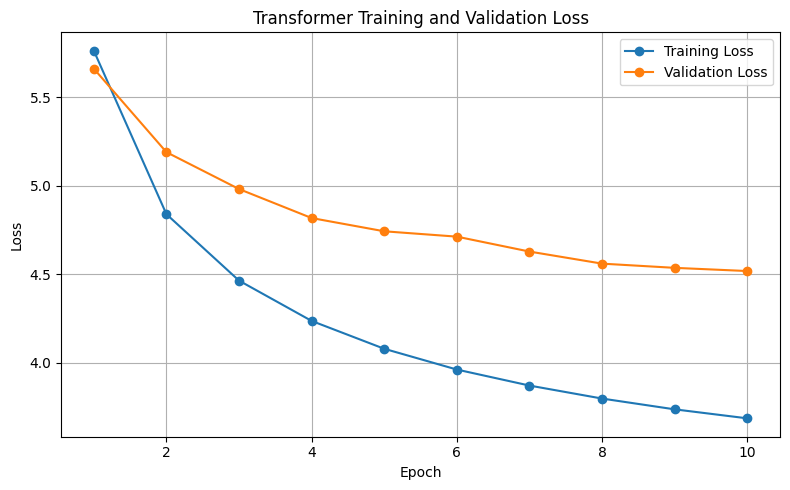

In [ ]:
# ============================================================
# STEP 34: PLOT AND SAVE TRANSFORMER LOSS CURVE
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import os


# Load saved training history
history_df = pd.read_csv(
    TRANSFORMER_HISTORY_PATH
)

print("Training history loaded:")
print(history_df)


# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["validation_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Transformer Training and Validation Loss"
)

plt.legend()
plt.grid(True)

plt.tight_layout()


# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

TRANSFORMER_LOSS_PLOT_PATH = os.path.join(
    RESULTS_PLOTS_DIR,
    "transformer_loss_curve.png"
)

plt.savefig(
    TRANSFORMER_LOSS_PLOT_PATH,
    dpi=300,
    bbox_inches="tight"
)

print(
    "\nTransformer loss curve saved at:"
)

print(
    TRANSFORMER_LOSS_PLOT_PATH
)

plt.show()

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_ROOT = "/content/drive/MyDrive/NNDL_English_Hindi_Translator"

print("Project exists:", os.path.exists(PROJECT_ROOT))
print("Transformer folder exists:",
      os.path.exists(f"{PROJECT_ROOT}/saved_models/transformer"))

Mounted at /content/drive
Project exists: True
Transformer folder exists: True


In [2]:
import os

required_files = {
    "train data": f"{PROJECT_ROOT}/data/processed/train_clean_300k.parquet",
    "validation data": f"{PROJECT_ROOT}/data/processed/validation_clean.parquet",
    "english tokenizer": f"{PROJECT_ROOT}/tokenizers/english_bpe.model",
    "hindi tokenizer": f"{PROJECT_ROOT}/tokenizers/hindi_bpe.model",
}

for name, path in required_files.items():
    print(f"{name:20} -> {os.path.exists(path)}")

train data           -> True
validation data      -> True
english tokenizer    -> True
hindi tokenizer      -> True
